## Compute the performance metrics using

In [2]:
!ls

all_algos.md	  LICENSE		sjaffe_accuracy.tex
bedl_experiments  pyldl			sjaffe_conformal.tex
build		  python_ldl.egg-info	sjaffe_per_label_fsc.tex
dataset		  README.md		tests
dataset_splits	  results		test.sh
demo		  setup.py		visualization
docs		  simple_kernel.sbatch


In [3]:
import sys, pathlib
BEDL = pathlib.Path("/project/6004619/dcs01/PyLDL/bedl_experiments")
if str(BEDL) not in sys.path:
    sys.path.insert(0, str(BEDL))

from accuracy_metrics import run_metrics    # note: no `bedl_experiments.` prefix

E0000 00:00:1779495412.456929 2732666 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779495412.459830 2732666 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779495412.468020 2732666 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779495412.468030 2732666 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779495412.468033 2732666 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779495412.468034 2732666 computation_placer.cc:177] computation placer already registered. Please check linka

In [4]:
import importlib
import accuracy_metrics
from accuracy_metrics import run_metrics

importlib.reload(accuracy_metrics)

<module 'accuracy_metrics' from '/project/6004619/dcs01/PyLDL/bedl_experiments/accuracy_metrics.py'>

In [4]:
list(range(0, 2))

[0, 1]

In [ ]:
from itertools import product
from joblib import Parallel, delayed

from accuracy_metrics import run_metrics

MODELS = ['multiBelief', 'EDL', 'BEDL', 'BOOJUM', 'AA_BP', 'SNEFY_LDL', 
          'EDL_BAYES', 'BEDL_BAYES', 'BOOJUM_BAYES']
MODELS = ['multiBelief', 'EDL', 'BEDL', 'AA_BP', 'SNEFY_LDL']
DATASETS = ['Yeast_spo5', 'Human_Gene']
FOLDS    = list(range(10))

HYPERPARAMS = {
    "batch_size": 32,
    "dropout_rate": 0.2,
    "learning_rate": 0.01,
    "max_epochs": 600,
    "minimum": 100,
    "n_hidden": 64,
    "n_latent": 16,
    "patience": 10,
    "weight_decay": 0.001
  }

tasks = list(product(MODELS, DATASETS, FOLDS))

def _run(model, dataset, fold):
    # Force CPU per worker so they don't fight over the GPU.
    # Remove these two lines if you want GPU and are limiting n_jobs accordingly.
    import os
    os.environ["CUDA_VISIBLE_DEVICES"] = ""

    return run_metrics(model, dataset, fold,
                       hyperparams=HYPERPARAMS,
                       n_splits=3, val_size=0.1, bin_count=4)

results = Parallel(n_jobs=-1, backend="loky", verbose=10)(
    delayed(_run)(model, dataset, fold)
    for model, dataset, fold in tasks
)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
E0000 00:00:1779493796.567517  560306 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779493796.567542  560292 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779493796.567728  560272 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779493796.567547  560290 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779493796.567608  560266 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779493796.567548  560317 cuda_dnn.c

In [2]:
import sys, pathlib
BEDL = pathlib.Path("/project/6004619/dcs01/PyLDL/bedl_experiments")
if str(BEDL) not in sys.path:
    sys.path.insert(0, str(BEDL))

from accuracy_metrics import run_metrics    # note: no `bedl_experiments.` prefix


E0000 00:00:1779312185.164264 3483783 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779312185.829988 3483783 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779312188.228976 3483783 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779312188.229018 3483783 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779312188.229022 3483783 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779312188.229025 3483783 computation_placer.cc:177] computation placer already registered. Please check linka

In [10]:
run_metrics('BOOJUM', 'SJAFFE', 0, 
    hyperparams=HYPERPARAMS, n_splits=1, val_size=0.1, bin_count=5)

## Test pipeline for a single model

In [7]:
HYPERPARAMS = {
    "batch_size": 32,
    "dropout_rate": 0.2,
    "learning_rate": 0.01,
    "max_epochs": 600,
    "minimum": 200,
    "n_hidden": 64,
    "n_latent": 16,
    "patience": 10,
    "weight_decay": 0.001
  }

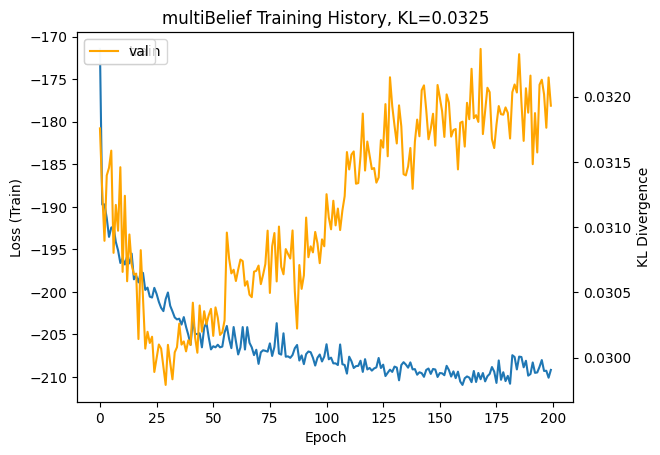

In [8]:
import importlib
import helpers

importlib.reload(helpers)

fit_best_model = helpers.fit_best_model
plot_history = helpers.plot_history
load_data_fold = helpers.load_data_fold
from pyldl.metrics import score
from sklearn.model_selection import train_test_split

X_train, D_train, X_test, D_test = load_data_fold('Yeast_spo5', 0)  # Just to check that it works
X_train, X_valid, D_train, D_valid = train_test_split(X_train, D_train, test_size=0.2, random_state=42)

train_data = {'X': X_train, 'D': D_train}
valid_data = {'X': X_valid, 'D': D_valid}

MOEDLS = ['multiBelief']
for model in MOEDLS:
    trained_model, history = fit_best_model(model, 'Yeast_spo5', 0, train_data=train_data, valid_data=valid_data, hyperparams=HYPERPARAMS)
    D = trained_model.predict(X_test)
    kl = score(D, D_test, metrics=['kl_divergence'])
    plot_history(history, title=f'{model} Training History, KL={kl[0]:.4f}')


In [6]:
import numpy as np
print(D.shape)
np.sum(D, axis=1)

(22, 6)


array([0.82868594, 0.8353957 , 0.85645145, 0.79973817, 0.81946766,
       0.8466254 , 0.84577364, 0.85444564, 0.8177679 , 0.816366  ,
       0.82512665, 0.8603768 , 0.8590611 , 0.8424815 , 0.8413843 ,
       0.85147077, 0.8355946 , 0.8559244 , 0.8579843 , 0.86470485,
       0.79877484, 0.8146106 ], dtype=float32)

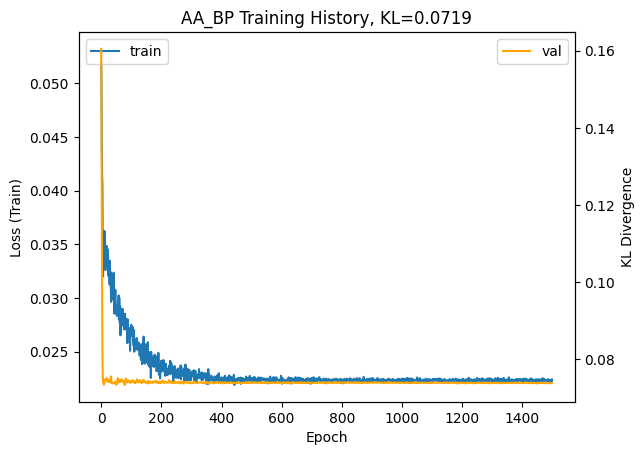

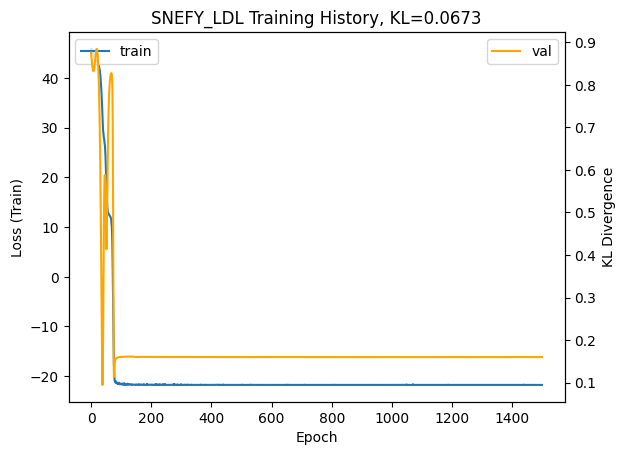

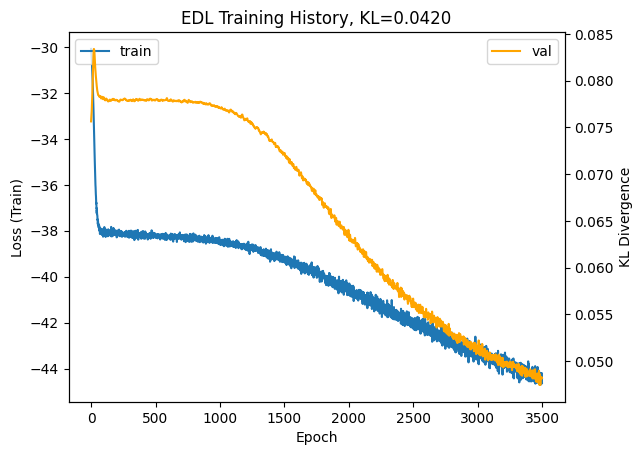

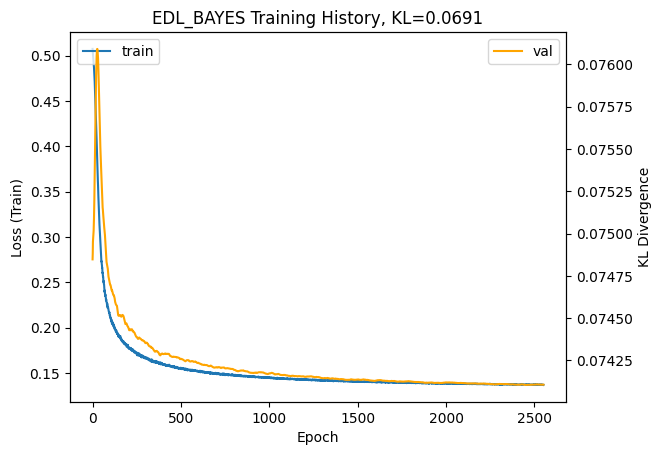

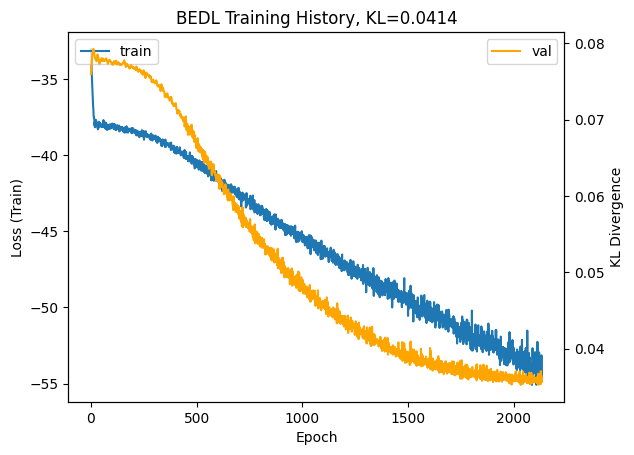

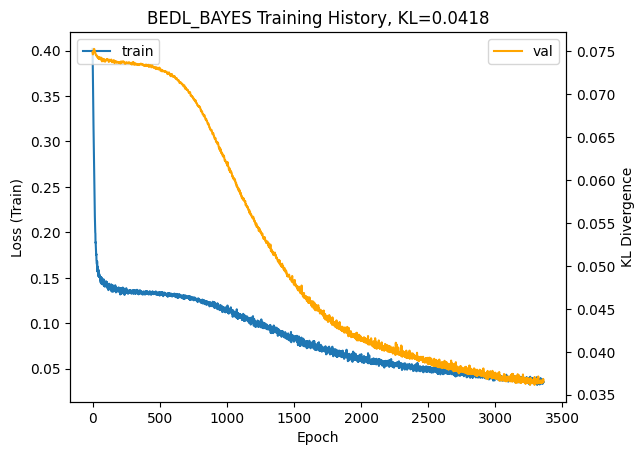

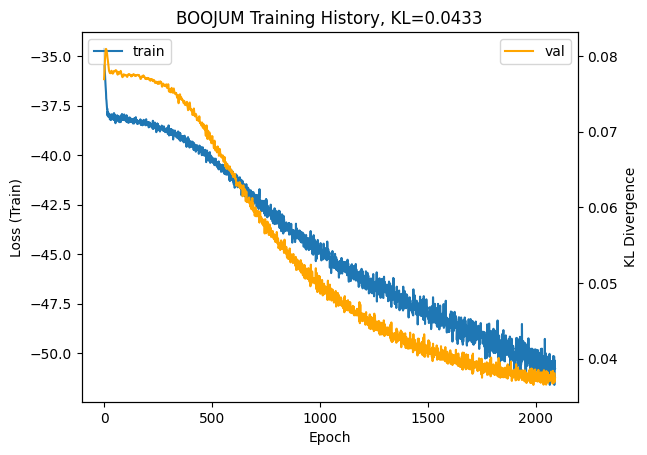

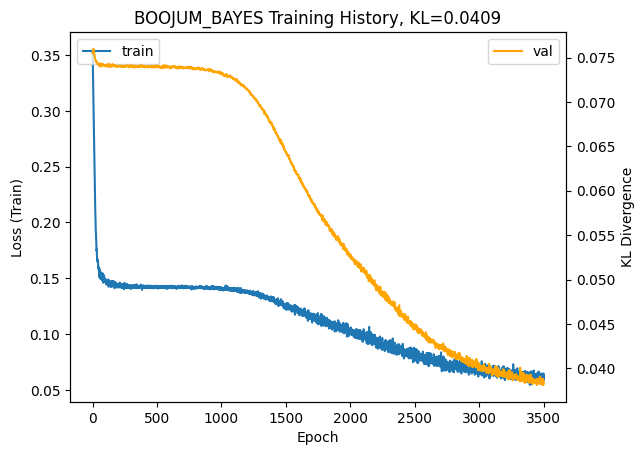

In [6]:
import importlib
import helpers

importlib.reload(helpers)

fit_best_model = helpers.fit_best_model
plot_history = helpers.plot_history
load_data_fold = helpers.load_data_fold
from pyldl.metrics import score
from sklearn.model_selection import train_test_split

X_train, D_train, X_test, D_test = load_data_fold('SJAFFE', 0)  # Just to check that it works
X_train, X_valid, D_train, D_valid = train_test_split(X_train, D_train, test_size=0.2, random_state=42)

train_data = {'X': X_train, 'D': D_train}
valid_data = {'X': X_valid, 'D': D_valid}

MOEDLS = ['AA_BP', 'SNEFY_LDL', 'EDL', 'EDL_BAYES', 'BEDL', 'BEDL_BAYES', 'BOOJUM', 'BOOJUM_BAYES']
for model in MOEDLS:
    trained_model, history = fit_best_model(model, 'SJAFFE', 0, train_data=train_data, valid_data=valid_data, hyperparams=HYPERPARAMS)
    D = trained_model.predict(X_test)
    kl = score(D, D_test, metrics=['kl_divergence'])
    plot_history(history, title=f'{model} Training History, KL={kl[0]:.4f}')

# edl_model, edl_history = fit_best_model('EDL', 'SJAFFE', 0, train_data=train_data, valid_data=valid_data, hyperparams=HYPERPARAMS)
# EDL_D = edl_model.predict(X_test)
# EDL_KL = score(EDL_D, D_test, metrics=['kl_divergence'])
# plot_history(edl_history, title=f'EDL Training History, KL={EDL_KL[0]:.4f}')

# edl_bayes_model, edl_bayes_history = fit_best_model('EDL_BAYES', 'SJAFFE', 0, train_data=train_data, valid_data=valid_data, hyperparams=HYPERPARAMS)
# plot_history(edl_bayes_history, title='EDL_BAYES Training History')

# bedl_model, bedl_history = fit_best_model('BEDL', 'SJAFFE', 0, train_data=train_data, valid_data=valid_data, hyperparams=HYPERPARAMS)
# plot_history(bedl_history, title='BEDL Training History')

# bedl_bayes_model, bedl_bayes_history = fit_best_model('BEDL_BAYES', 'SJAFFE', 0, train_data=train_data, valid_data=valid_data, hyperparams=HYPERPARAMS)
# plot_history(bedl_bayes_history, title='BEDL_BAYES Training History')

# boojum_model, boojum_history = fit_best_model('BOOJUM', 'SJAFFE', 0, train_data=train_data, valid_data=valid_data, hyperparams=HYPERPARAMS)
# plot_history(boojum_history, title='BOOJUM Training History')

# boojum_bayes_model, boojum_bayes_history = fit_best_model('BOOJUM_BAYES', 'SJAFFE', 0, train_data=train_data, valid_data=valid_data, hyperparams=HYPERPARAMS)
# plot_history(boojum_bayes_history, title='BOOJUM_BAYES Training History')



In [10]:
D

array([[0.17734446, 0.1866865 , 0.14549614, 0.15439838, 0.17312634,
        0.16294818],
       [0.13678569, 0.17097244, 0.14219028, 0.19669569, 0.20158435,
        0.15177153],
       [0.0570648 , 0.18274955, 0.11943127, 0.2153111 , 0.25647277,
        0.16897047],
       [0.20033562, 0.18048793, 0.15255708, 0.1448016 , 0.16268344,
        0.15913427],
       [0.26480678, 0.16630366, 0.1503227 , 0.13398425, 0.13998607,
        0.14459652],
       [0.09768278, 0.18049741, 0.16295858, 0.18164214, 0.20224136,
        0.17497776],
       [0.0928397 , 0.1745936 , 0.17656857, 0.1811742 , 0.19833386,
        0.17649005],
       [0.12378385, 0.16551995, 0.13616136, 0.22118707, 0.2107522 ,
        0.14259562],
       [0.20666462, 0.1372989 , 0.247478  , 0.12865824, 0.12686674,
        0.1530336 ],
       [0.26124907, 0.16710162, 0.1534475 , 0.12556635, 0.14001942,
        0.15261589],
       [0.15718447, 0.14994209, 0.24141589, 0.14004485, 0.14459267,
        0.16682014],
       [0.12232622, 0

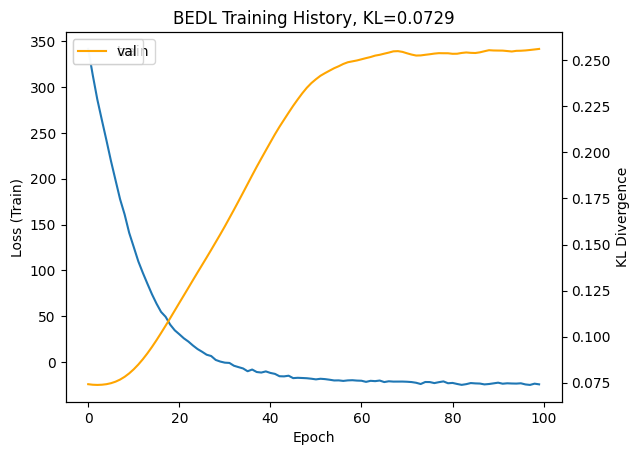

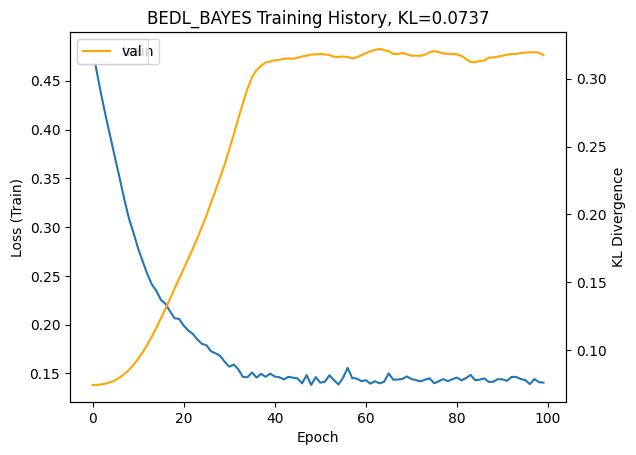

In [18]:
import importlib
import helpers

importlib.reload(helpers)

fit_best_model = helpers.fit_best_model
plot_history = helpers.plot_history
load_data_fold = helpers.load_data_fold
from pyldl.metrics import score
from sklearn.model_selection import train_test_split

X_train, D_train, X_test, D_test = load_data_fold('SJAFFE', 0)  # Just to check that it works
X_train, X_valid, D_train, D_valid = train_test_split(X_train, D_train, test_size=0.2, random_state=42)

train_data = {'X': X_train, 'D': D_train}
valid_data = {'X': X_valid, 'D': D_valid}

MOEDLS = ['BEDL', 'BEDL_BAYES']
for model in MOEDLS:
    trained_model, history = fit_best_model(model, 'SJAFFE', 0, train_data=train_data, valid_data=valid_data, hyperparams=HYPERPARAMS)
    D = trained_model.predict(X_test)
    kl = score(D, D_test, metrics=['kl_divergence'])
    plot_history(history, title=f'{model} Training History, KL={kl[0]:.4f}')

In [14]:
np.abs(D_valid - D_pred_cal)

array([[0.08090908, 0.04398031, 0.04513351, 0.02312053, 0.05855366,
        0.0003881 ],
       [0.05002786, 0.03979388, 0.03782673, 0.06922232, 0.07487914,
        0.01645304],
       [0.14061106, 0.00355681, 0.02664243, 0.02499977, 0.04906754,
        0.03634455],
       [0.18005382, 0.03779148, 0.02366955, 0.04026848, 0.04622465,
        0.03209969],
       [0.11550661, 0.0491097 , 0.02806321, 0.04444283, 0.01213595,
        0.07064057],
       [0.051835  , 0.04707147, 0.04229438, 0.04841686, 0.10812562,
        0.01534167],
       [0.09644975, 0.08515143, 0.068238  , 0.02800549, 0.06841799,
        0.03912378],
       [0.00349381, 0.00871237, 0.00451199, 0.0383385 , 0.00959129,
        0.02945373],
       [0.03842394, 0.00038587, 0.12668392, 0.03778228, 0.05491002,
        0.00404652],
       [0.07529931, 0.07941553, 0.07061381, 0.01493177, 0.04540808,
        0.00615782],
       [0.12451502, 0.02308096, 0.05467838, 0.01387884, 0.01488964,
        0.01798716],
       [0.04681943, 0

In [13]:
k*np.sqrt(var_cal)

array([[0.00417895, 0.00454663, 0.00436382, 0.00447235, 0.00461479,
        0.00433096],
       [0.00401076, 0.00455943, 0.00431633, 0.00451168, 0.0046685 ,
        0.00433604],
       [0.00406037, 0.00455639, 0.00433091, 0.00450085, 0.00465348,
        0.00433523],
       [0.00468013, 0.00445821, 0.00446816, 0.00430121, 0.00439683,
        0.00426857],
       [0.00458877, 0.00448116, 0.00445394, 0.00433982, 0.00444455,
        0.00428632],
       [0.00401076, 0.00455943, 0.00431633, 0.00451168, 0.0046685 ,
        0.00433604],
       [0.00457485, 0.00448434, 0.00445156, 0.00434536, 0.00445146,
        0.00428873],
       [0.00435485, 0.00452512, 0.00440728, 0.00442258, 0.00454937,
        0.00431798],
       [0.00444825, 0.00450987, 0.00442754, 0.00439203, 0.00451021,
        0.00430749],
       [0.00448397, 0.00450327, 0.00443474, 0.00437951, 0.00449433,
        0.00430276],
       [0.00512514, 0.00427192, 0.00448935, 0.00403077, 0.00407526,
        0.00411309],
       [0.00451499, 0

In [9]:
D_pred_cal, var_cal, _ = bedl_bayes_model.predict(X_valid, return_uncertainty=True)
cal_scores = np.abs(D_valid - D_pred_cal)/(k*np.sqrt(var_cal))         # (N_cal, K)
cal_scores

array([[19.36109784,  9.67316729, 10.34266241,  5.16966243, 12.6882567 ,
         0.08961008],
       [12.47340159,  8.72781679,  8.76362259, 15.34292474, 16.03924133,
         3.79448398],
       [34.63011191,  0.7806209 ,  6.15168773,  5.55445368, 10.54425912,
         8.38352499],
       [38.47198753,  8.47682287,  5.29738405,  9.36213605, 10.51317151,
         7.52001891],
       [25.17160132, 10.95914852,  6.30076007, 10.24070238,  2.73051996,
        16.48047102],
       [12.92397423, 10.32397907,  9.7986796 , 10.73145528, 23.16069428,
         3.53817463],
       [21.08260526, 18.98860548, 15.32900053,  6.44491411, 15.36979918,
         9.12245571],
       [ 0.80228144,  1.92533422,  1.02375779,  8.66881523,  2.10826948,
         6.82118721],
       [ 8.63799054,  0.08556227, 28.61268859,  8.60245946, 12.17461058,
         0.93941504],
       [16.79299273, 17.63509718, 15.92287679,  3.40946005, 10.10341715,
         1.43113433],
       [24.2949372 ,  5.40294319, 12.17958207,  3.

In [15]:
n_cal   = len(cal_scores)
q_level = min(1.0, ((n_cal + 1) * confidence) / n_cal)
q_hat = np.quantile(cal_scores, q_level, axis=0, method='higher')   # (K,)
print(q_level)
q_hat

0.9230769230769231


array([38.47198753, 18.7187182 , 32.2333121 , 15.34292474, 19.24867557,
       12.66129463])

In [16]:
D_pred, var, _ = bedl_bayes_model.predict(X_test, return_uncertainty=True)
lower = D_pred - k*q_hat*np.sqrt(var)
upper = D_pred + k*q_hat*np.sqrt(var)

In [18]:
covered = (D_test >= lower) & (D_test <= upper)  
covered

array([[ True,  True,  True,  True,  True,  True],
       [ True,  True,  True, False,  True,  True],
       [ True,  True,  True,  True, False,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True, False],
       [ True, False,  True,  True,  True,  True],
       [ True,  True, False,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True,  True, False,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True,  True, False,  True,  True,  True],
       [ True,  True,  True, False,  True,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True, False,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True,  True,  True, False,  True,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  T

In [19]:
covered.mean(axis=0)  

array([0.95454545, 0.90909091, 0.86363636, 0.86363636, 0.95454545,
       0.95454545])

In [20]:
float(covered.all(axis=1).mean())

0.5

In [22]:
K = D_test.shape[1]
K

6

In [32]:
bin_count = 4
edges = np.quantile(D_pred[:, 0],
    np.linspace(0., 1., bin_count + 1))
edges

array([0.13229477, 0.1335926 , 0.14237637, 0.16445544, 0.23753653])

In [33]:
np.linspace(0., 1., bin_count + 1)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [34]:
D_pred[:, 0]

array([0.16380022, 0.14061171, 0.13229477, 0.176843  , 0.22255763,
       0.13229477, 0.13229477, 0.13642688, 0.22635992, 0.23753653,
       0.15673304, 0.14517051, 0.13229477, 0.13917695, 0.14117071,
       0.14358203, 0.16440943, 0.13264784, 0.14087781, 0.13229477,
       0.1897061 , 0.16447078], dtype=float32)

In [37]:
bin_idx = np.clip(np.digitize(D_pred[:, 0], edges[1:-1]),
                          0, bin_count - 1)
bin_idx

array([2, 1, 0, 3, 3, 0, 0, 1, 3, 3, 2, 2, 0, 1, 1, 2, 2, 0, 1, 0, 3, 3])

In [38]:
mask = bin_idx == 0
mask

array([False, False,  True, False, False,  True,  True, False, False,
       False, False, False,  True, False, False, False, False,  True,
       False,  True, False, False])

In [39]:
covered[mask, 0].mean()

1.0

In [40]:
K = D_test.shape[1]
per_bin_fsc = np.full((K, bin_count), np.nan, dtype=float)
for k in range(K):
    edges = np.quantile(D_pred[:, k],
                        np.linspace(0., 1., bin_count + 1))
    # np.digitize returns indices in [1, bin_count] for interior edges
    # — clipping puts boundary cases into the outer bins.
    bin_idx = np.clip(np.digitize(D_pred[:, k], edges[1:-1]),
                        0, bin_count - 1)
    for b in range(bin_count):
        mask = bin_idx == b
        if mask.any():
            per_bin_fsc[k, b] = covered[mask, k].mean()

per_bin_fsc

array([[1.        , 1.        , 1.        , 0.83333333],
       [1.        , 0.8       , 1.        , 0.83333333],
       [0.83333333, 1.        , 0.8       , 0.83333333],
       [1.        , 0.8       , 0.8       , 0.83333333],
       [1.        , 1.        , 1.        , 0.83333333],
       [0.83333333, 1.        , 1.        , 1.        ]])

In [42]:
4/6

0.6666666666666666